# 01 — Exploratory Data Analysis

This notebook explores these datasets:

1. **Financial PhraseBank** — financial news sentences labeled by sentiment.
2. A **no-agent baseline** sentiment classifier (TF-IDF + logistic regression).
3. **yfinance** — two years of daily market data for one ticker.
4. An optional LLM comparison via the free Hugging Face Inference API.

All data sources are documented in [`docs/sources.md`](../docs/sources.md).


## 1. Setup

In [10]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Deterministic results throughout the notebook.
RANDOM_STATE = 42

# Paths are resolved relative to the repository root (the parent of notebooks/).
REPO_ROOT = Path.cwd().parent
assert (REPO_ROOT / "pyproject.toml").exists(), "run this notebook from notebooks/"
DATA_RAW = REPO_ROOT / "data" / "raw"
DATA_PROCESSED = REPO_ROOT / "data" / "processed"
DATA_RAW.mkdir(parents=True, exist_ok=True)
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_colwidth", 90)
plt.rcParams["figure.dpi"] = 110
print("Data folders: data/raw and data/processed (under the repository root)")


Data folders: data/raw and data/processed (under the repository root)


## 2. Financial PhraseBank

Downloads the original `FinancialPhraseBank-v1.0` archive and parses the `Sentences_50Agree` file (`sentence@label` lines, `iso-8859-1`). Dataset summary, license, and citation: [`docs/sources.md`](../docs/sources.md).


In [11]:
import urllib.request
import zipfile

ZIP_URL = (
    "https://huggingface.co/datasets/financial_phrasebank/resolve/main/data/"
    "FinancialPhraseBank-v1.0.zip"
)
zip_path = DATA_RAW / "FinancialPhraseBank-v1.0.zip"
if not zip_path.exists():
    urllib.request.urlretrieve(ZIP_URL, zip_path)

LABELS = ["negative", "neutral", "positive"]  # order per the dataset's loader script
records = []
with zipfile.ZipFile(zip_path) as archive:
    raw = archive.read("FinancialPhraseBank-v1.0/Sentences_50Agree.txt").decode(
        "iso-8859-1"
    )
for line in raw.splitlines():
    line = line.strip()
    if not line:
        continue
    sentence, label = line.rsplit("@", 1)
    records.append({"sentence": sentence.strip(), "label": LABELS.index(label)})

phrasebank = pd.DataFrame(records)
phrasebank["label_name"] = phrasebank["label"].map(dict(enumerate(LABELS)))
phrasebank.to_csv(DATA_RAW / "financial_phrasebank_50agree.csv", index=False)

print(f"Loaded {len(phrasebank)} sentences; labels: {LABELS}")
phrasebank[["sentence", "label_name"]].head()

Loaded 4846 sentences; labels: ['negative', 'neutral', 'positive']


,sentence,label_name
0,"According to Gran , the company has no plans to move all production to Russia , althou...",neutral
1,"Technopolis plans to develop in stages an area of no less than 100,000 square meters i...",neutral
2,The international electronic industry company Elcoteq has laid off tens of employees f...,negative
3,With the new production plant the company would increase its capacity to meet the expe...,positive
4,"According to the company 's updated strategy for the years 2009-2012 , Basware targets...",positive


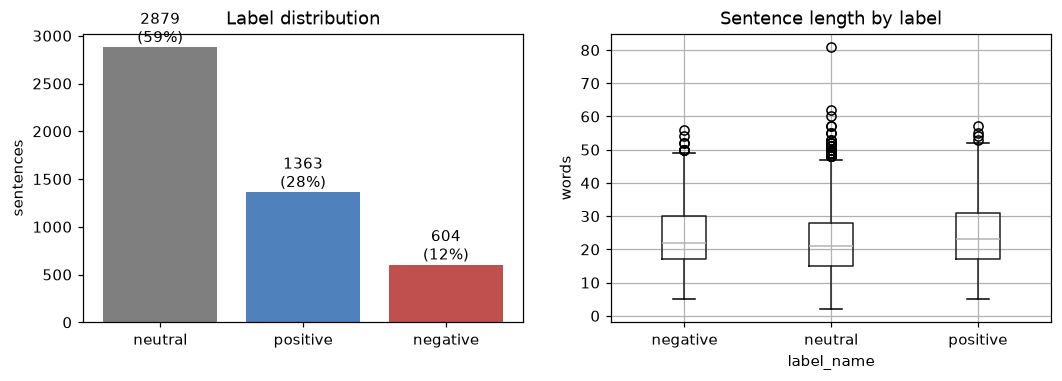

,count,mean,std,min,25%,50%,75%,max
label_name,,,,,,,,
negative,604.0,23.9,9.9,5.0,17.0,22.0,30.0,56.0
neutral,2879.0,22.2,9.8,2.0,15.0,21.0,28.0,81.0
positive,1363.0,24.7,10.1,5.0,17.0,23.0,31.0,57.0



--- neutral ---
 • According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .
 • Technopolis plans to develop in stages an area of no less than 100,000 square meters in order to host companies working in computer technologies and telecommunications , the statement said .

--- positive ---
 • With the new production plant the company would increase its capacity to meet the expected increase in demand and would improve the use of raw materials and therefore increase the production profitability .
 • According to the company 's updated strategy for the years 2009-2012 , Basware targets a long-term net sales growth in the range of 20 % -40 % with an operating profit margin of 10 % -20 % of net sales .

--- negative ---
 • The international electronic industry company Elcoteq has laid off tens of employees from its Tallinn facility ; contrary to earlier layoffs the company contracted the ranks of its office workers , the 

In [12]:
colors = {"negative": "#c0504d", "neutral": "#7f7f7f", "positive": "#4f81bd"}
counts = phrasebank["label_name"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].bar(counts.index, counts.values, color=[colors[c] for c in counts.index])
axes[0].set_title("Label distribution")
axes[0].set_ylabel("sentences")
for i, (name, n) in enumerate(counts.items()):
    axes[0].text(i, n, f"{n}\n({n / len(phrasebank):.0%})", ha="center", va="bottom")

phrasebank["n_words"] = phrasebank["sentence"].str.split().str.len()
phrasebank.boxplot(column="n_words", by="label_name", ax=axes[1])
axes[1].set_title("Sentence length by label")
axes[1].set_ylabel("words")
fig.suptitle("")
plt.show()

phrasebank.to_csv(DATA_PROCESSED / "phrasebank_with_lengths.csv", index=False)
display(phrasebank.groupby("label_name")["n_words"].describe().round(1))
for label in counts.index:
    print(f"\n--- {label} ---")
    for s in phrasebank.loc[phrasebank["label_name"] == label, "sentence"].head(2):
        print(" •", s)

## 3. No-agent baseline: TF-IDF + logistic regression

Trains a TF-IDF + logistic regression classifier on the sentences, then reports validation accuracy, per-class metrics, a confusion matrix, and sample predictions.


In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    phrasebank["sentence"],
    phrasebank["label_name"],
    test_size=0.25,
    stratify=phrasebank["label_name"],
    random_state=RANDOM_STATE,
)

vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)

baseline = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
baseline.fit(X_train_tfidf, y_train)
val_accuracy = baseline.score(X_val_tfidf, y_val)

print(
    f"Training examples: {len(X_train)}, validation examples: {len(X_val)}, "
    f"vocabulary size: {len(vectorizer.vocabulary_)}"
)
print(f"\nValidation accuracy: {val_accuracy:.3f}\n")
print(classification_report(y_val, baseline.predict(X_val_tfidf)))

Training examples: 3634, validation examples: 1212, vocabulary size: 11898

Validation accuracy: 0.748

              precision    recall  f1-score   support

    negative       0.76      0.42      0.54       151
     neutral       0.75      0.94      0.83       720
    positive       0.75      0.49      0.59       341

    accuracy                           0.75      1212
   macro avg       0.75      0.61      0.65      1212
weighted avg       0.75      0.75      0.73      1212



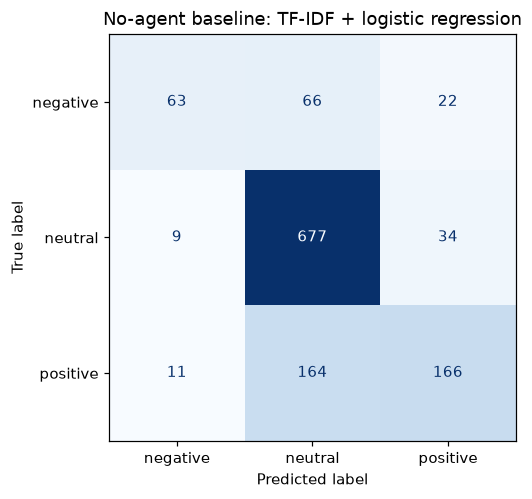

,sentence,true label,predicted
403,The agreement with JM is one in a series of contracts that TeliaSonera has signed in r...,neutral,positive
639,"By combining its existing solutions into a single platform , Comptel said that it has ...",positive,positive
1196,Chief Financial Officer Jim Heindlmeyer said Beyond Oblivion is in advanced talks with...,neutral,neutral
2699,"Under the changes envisaged , HK Ruokatalo would reduce its number of industrial place...",neutral,neutral
2654,The new activity will incur an investment of about 5 MEUR .,neutral,neutral


In [14]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    baseline, X_val_tfidf, y_val, cmap="Blues", colorbar=False
)
plt.title("No-agent baseline: TF-IDF + logistic regression")
plt.show()

sample = X_val.sample(5, random_state=RANDOM_STATE)
pd.DataFrame(
    {
        "sentence": sample,
        "true label": y_val.loc[sample.index],
        "predicted": baseline.predict(vectorizer.transform(sample)),
    }
)

## 4. Market data: yfinance

Downloads two years of daily prices for one ticker and computes return and volatility statistics.


In [15]:
import yfinance as yf

TICKER = "AAPL"
prices = yf.Ticker(TICKER).history(period="2y", auto_adjust=True)
prices.to_csv(DATA_RAW / f"{TICKER.lower()}_2y_daily.csv")

print(f"{len(prices)} rows, {prices.index.min().date()} to {prices.index.max().date()}")
prices.tail(3)

501 rows, 2024-09-26 to 2026-09-25


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-09-23 00:00:00-04:00,341.079987,341.799988,335.500000,337.019989,31658800,0.0,0.0
2026-09-24 00:00:00-04:00,336.720001,338.910004,334.299988,335.920013,24733100,0.0,0.0
2026-09-25 00:00:00-04:00,336.040009,341.670013,334.529999,341.070007,29950100,0.0,0.0


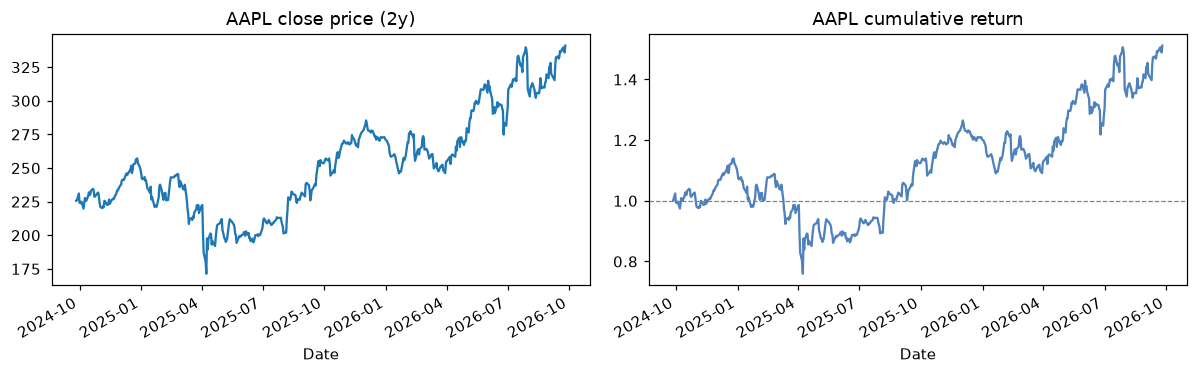

last close               341.070
total return (2y)          0.512
annualized volatility      0.288
max daily gain             0.153
max daily loss            -0.092
dtype: float64

In [16]:
returns = prices["Close"].pct_change().dropna()
stats = pd.Series(
    {
        "last close": prices["Close"].iloc[-1],
        "total return (2y)": prices["Close"].iloc[-1] / prices["Close"].iloc[0] - 1,
        "annualized volatility": returns.std() * 252 ** 0.5,
        "max daily gain": returns.max(),
        "max daily loss": returns.min(),
    }
)

returns.rename("daily_return").to_frame().assign(
    cumulative=lambda d: (1 + d["daily_return"]).cumprod()
).to_csv(DATA_PROCESSED / f"{TICKER.lower()}_returns.csv")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
prices["Close"].plot(ax=axes[0], title=f"{TICKER} close price (2y)")
(1 + returns).cumprod().plot(
    ax=axes[1], title=f"{TICKER} cumulative return", color="#4f81bd"
)
axes[1].axhline(1, color="gray", lw=0.8, linestyle="--")
plt.tight_layout()
plt.show()

display(stats.round(3))

## 5. Optional: how an agent sees it

Sends three validation sentences to a small instruction-tuned LLM via the free Hugging Face Inference API and prints its verdict next to the baseline's. Requires `HF_TOKEN` in `.env` (see `.env.example`); the cell is skipped without it.


In [17]:
import os

from dotenv import load_dotenv

load_dotenv(REPO_ROOT / ".env")
token = os.getenv("HF_TOKEN")

if not token:
    print("HF_TOKEN not set — skipping the LLM comparison.")
else:
    from huggingface_hub import InferenceClient

    client = InferenceClient(api_key=token)
    examples = X_val.sample(3, random_state=RANDOM_STATE)
    baseline_preds = baseline.predict(vectorizer.transform(examples))
    for text, base in zip(examples, baseline_preds):
        try:
            reply = client.chat_completion(
                model="HuggingFaceTB/SmolLM2-1.7B-Instruct",
                messages=[
                    {
                        "role": "user",
                        "content": (
                            "Classify the sentiment of this financial news sentence "
                            "as positive, negative, or neutral. Answer with one word.\n\n"
                            f"Sentence: {text}"
                        ),
                    }
                ],
                max_tokens=5,
            ).choices[0].message.content.strip()
        except Exception as exc:
            reply = f"(inference failed: {exc})"
        print(f"baseline [{base:>8}] | agent [{reply}]")
        print(f"  {text[:90]}\n")

HF_TOKEN not set — skipping the LLM comparison.


## 6. Takeaways

In [18]:
label_mix = ", ".join(f"{k} {v / len(phrasebank):.0%}" for k, v in counts.items())
print(f"- Financial PhraseBank (Sentences_50Agree): {len(phrasebank)} sentences; labels: {label_mix}.")
print(f"- Baseline (TF-IDF + logistic regression) validation accuracy: {val_accuracy:.1%}.")
print(f"- {TICKER}: {len(prices)} trading days; 2y total return {stats['total return (2y)']:.0%}; annualized volatility {stats['annualized volatility']:.0%}.")


- Financial PhraseBank (Sentences_50Agree): 4846 sentences; labels: neutral 59%, positive 28%, negative 12%.
- Baseline (TF-IDF + logistic regression) validation accuracy: 74.8%.
- AAPL: 501 trading days; 2y total return 51%; annualized volatility 29%.
